# MECADOI stats

Questions: 

1. How many MECAs did we receive from eJP, and what do they look like?
2. For how many of these MECAs were depositions attempted, and how successful were they?
3. How many DOIs have we created?

All this information is in the MECADOI database.
I've fetched it from `s3://mecadoi-archives/batch/batch.sqlite3` to a local folder:

In [1]:
db_uri = "sqlite:////Users/eidens/Projects/mecadoi-archives/batch/batch.sqlite3"

In [2]:
import pandas

## Received MECAs

All files received from eJP get an entry in the `parsed_file` table.

The value for the `doi` column is read from the preprint DOI field in the MECA.
If the file is not a MECA or it doesn't have that field the value is `None`.

The file status is represented as an integer in the database.
For the mapping between status and number see `mecadoi.db.ParsedFile`.

In [3]:
query_received_files = """
SELECT
  doi,
  SUBSTR(SUBSTR(path, 65), 0, 14) AS manuscript,
  received_at,
  status
FROM parsed_file
ORDER BY received_at
"""
received_files = pandas.read_sql_query(
    query_received_files,
    db_uri,
    parse_dates=["received_at"],
    dtype={"status": "category"},
)
received_files["status"] = received_files["status"].replace(
    [1,       10,        20,                21,           22],
    ["Valid", "Invalid", "No Preprint DOI", "No Reviews", "Duplicate"]
)
received_files["received_at_year_month"] = received_files["received_at"].dt.to_period("M")
received_files

,doi,manuscript,received_at,status,received_at_year_month
0,10.1101/2020.01.16.909200,RC-2020-00182,2022-05-17 10:23:59.000000,Valid,2022-05
1,10.1101/2021.04.28.441815,RC-2021-00822,2022-05-19 03:00:15.000000,Valid,2022-05
2,10.1101/2022.01.28.478180,RC-2022-01269,2022-05-19 03:00:16.000000,Duplicate,2022-05
3,10.1101/2021.06.04.447106,RC-2021-00877,2022-05-19 03:00:17.000000,Valid,2022-05
4,None,RC-2022-01241,2022-05-19 03:00:17.000000,No Preprint DOI,2022-05
...,...,...,...,...,...
1362,10.1101/2025.01.09.632153,RC-2025-02865,2025-08-06 18:03:02.542905,Valid,2025-08
1363,10.1101/2025.04.02.646512,RC-2025-03014,2025-08-07 09:03:01.793231,Valid,2025-08
1364,10.1101/2025.05.13.653105,RC-2025-03035,2025-08-07 09:03:01.861231,Valid,2025-08
1365,10.1101/2025.05.09.653054,RC-2025-03031,2025-08-07 14:03:02.144097,Valid,2025-08


As of 2022-11-07, all received files were MECA archives:

- Around 1/8 did not have a preprint DOI.
- Another 1/8 had the preprint DOI of a MECA archive that had already been received.
- For the rest a deposition attempt could be made.

(status
 Valid              987
 No Preprint DOI    190
 Duplicate          187
 Invalid              3
 dtype: int64,
 <AxesSubplot:ylabel='Status of received MECAs'>)

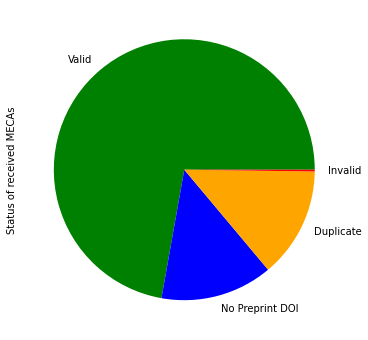

In [4]:
color_by_status = {
    "Valid": "green",
    "No Preprint DOI": "blue",
    "Duplicate": "orange",
    "Invalid": "red",
}
status_counts = received_files.value_counts("status")
status_counts, status_counts.plot.pie(
    colors=[color_by_status.get(x, 'grey') for x in status_counts.index],
    figsize=(11, 6),
    label="Status of received MECAs",
)

How many MECA archives are we receiving per month?

({'median # of MECAs received per month': 34},
 <AxesSubplot:xlabel='Month', ylabel='# of received MECAs'>)

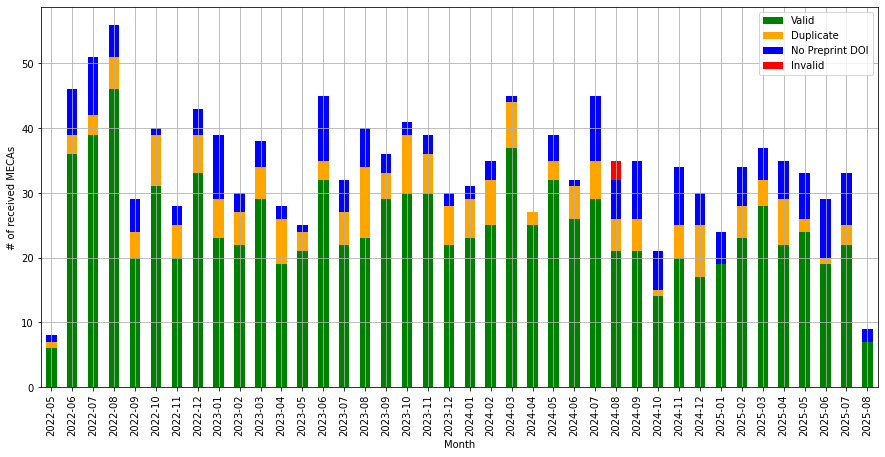

In [5]:
counts_by_month_and_status = pandas.DataFrame({
    state: received_files[received_files["status"] == state].value_counts("received_at_year_month")
    for state in received_files["status"].unique()
})
(
    {"median # of MECAs received per month": int(received_files.value_counts("received_at_year_month").median())},
    counts_by_month_and_status.plot.bar(
        color=color_by_status,
        figsize=(15, 7),
        grid=True,
        stacked=True,
        xlabel="Month",
        ylabel="# of received MECAs",
    ),
)

## Deposition Attempts

Each attempt also gets an entry in the database, in the `deposition_attempt` table.

Only for `Valid` (see above) MECA archives is a deposition attempt made.

The attempt status (i.e. result) is also represented as an integer in the database.
For the mapping between status and number see `mecadoi.db.DepositionAttempt`.

There are multiple failure states:

- Generating the necesssary deposition file could fail. This usually points to a programming error.
- Before creating DOIs for reviews & replies we verify that what's in the MECA matches what EEB has:
    - There could already be DOIs assigned to a review or reply -> `DOIs Already Present`.
    - Or the amount of reviews and replies could differ -> `Deposition Verification Failed`.
- Finally, sending the deposition file to Crossref could fail, or they could reject it -> `Deposition Failed`.

In [6]:
query_attempted_depositions = """
SELECT
  p.doi AS doi,
  SUBSTR(SUBSTR(p.path, 65), 0, 14) AS manuscript,
  p.received_at AS received_at,
  p.status AS file_status,
  d.id AS id_deposition_attempt,
  d.attempted_at AS attempted_at,
  d.status AS deposition_status
FROM parsed_file AS p
JOIN deposition_attempt AS d
  ON d.id_parsed_file = p.id
ORDER BY id_deposition_attempt
"""
attempted_depositions = pandas.read_sql_query(
    query_attempted_depositions,
    db_uri,
    parse_dates=[
        "received_at",
        "attempted_at",
    ],
    dtype={
        "file_status": "category",
        "deposition_status": "category",
    },
)
attempted_depositions["file_status"] = attempted_depositions["file_status"].replace(
    [1,       10,        20,      21,          22],
    ["Valid", "Invalid", "No DOI", "No Reviews", "Duplicate"]
)
attempted_depositions["deposition_status"] = attempted_depositions["deposition_status"].replace(
    [1,                      2,                      10,                  20,                               21],
    ["Deposition Succeeded", "DOIs Already Present", "Deposition Failed", "Deposition Verification Failed", "Deposition Generation Failed"]
)
attempted_depositions["attempted_at_year_month"] = attempted_depositions["attempted_at"].dt.to_period("M")
attempted_depositions

,doi,manuscript,received_at,file_status,id_deposition_attempt,attempted_at,deposition_status,attempted_at_year_month
0,10.1101/2020.01.16.909200,RC-2020-00182,2022-05-17 10:23:59.000000,Valid,1,2020-05-20 00:00:00.000000,Deposition Succeeded,2020-05
1,10.1101/2022.04.18.488674,RC-2022-01437,2022-06-07 03:00:20.000000,Valid,2,2022-07-21 15:56:31.275488,Deposition Succeeded,2022-07
2,10.1101/2021.05.14.444132,RC-2021-01208,2022-06-18 03:00:04.000000,Valid,3,2022-07-25 14:14:29.693235,Deposition Succeeded,2022-07
3,10.1101/2020.05.14.094334,RC-2021-01049,2022-06-07 03:00:19.000000,Valid,4,2022-07-21 15:56:32.851794,Deposition Succeeded,2022-07
4,10.1101/2022.03.31.486562,RC-2022-01394,2022-07-07 21:03:01.800569,Valid,5,NaT,Deposition Verification Failed,NaT
...,...,...,...,...,...,...,...,...
26854,10.1101/2024.09.13.612912,RC-2024-02702,2024-11-13 10:03:01.430073,Valid,26855,2025-08-08 02:23:50.880528,Deposition Verification Failed,2025-08
26855,10.1101/627712,RC-2024-02829,2025-04-08 15:03:02.238695,Valid,26856,2025-08-08 02:23:51.074690,Deposition Verification Failed,2025-08
26856,10.1101/2025.02.05.636654,RC-2025-02906,2025-04-25 23:03:02.153763,Valid,26857,2025-08-08 02:23:51.260297,Deposition Verification Failed,2025-08
26857,approval pending at bioRxiv,RC-2021-01171,2025-06-16 23:03:03.584432,Valid,26858,2025-08-08 02:23:51.460334,Deposition Verification Failed,2025-08


Here's a look at all deposition attempts.

It includes a transition period where we had already created "legacy" DOIs for all Review Commons reviews and replies on EEB.
Then, we ran MECADOI for all MECAs received up to that point, and these overlapped with the "legacy" DOIs: some MECAs already had DOIs for their reviews and replies from the "legacy" depositions.
That is the source of all or most of the attempts with the `DOIs Already Present` status.

Also, for all MECAs where the latest deposition attempt status is `Deposition Verification Failed` (i.e. those where the MECA contains a different number of reviews and replies than EEB had) the deposition is retried periodically.
This is supposed to catch cases where reviews and replies are going up on EEB with some kind of delay, which does happen occasionally.
However, many reviews and replies are simply not made public at all and thus produce a large amount of attempts with this status.

(deposition_status
 Deposition Verification Failed    25985
 Deposition Succeeded                829
 DOIs Already Present                 44
 Deposition Failed                     1
 dtype: int64,
 <AxesSubplot:ylabel='Status of deposition attempts'>)

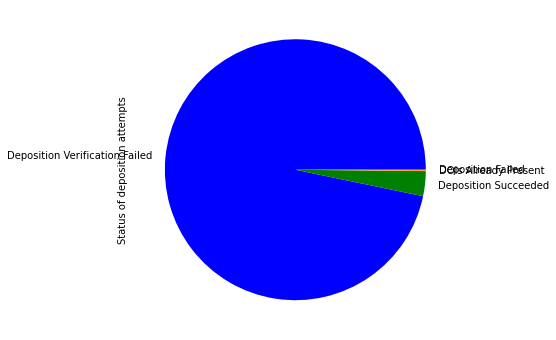

In [7]:
color_by_deposition_status = {
    "Deposition Succeeded": "green",
    "Deposition Verification Failed": "blue",
    "DOIs Already Present": "orange",
    "Deposition Failed": "red",
}
deposition_status_counts = attempted_depositions.value_counts("deposition_status")
deposition_status_counts, deposition_status_counts.plot.pie(
    colors=[color_by_deposition_status.get(x, 'grey') for x in deposition_status_counts.index],
    figsize=(11, 6),
    label="Status of deposition attempts",
)

The transition period to automated MECADOI depositions was in October 2022:

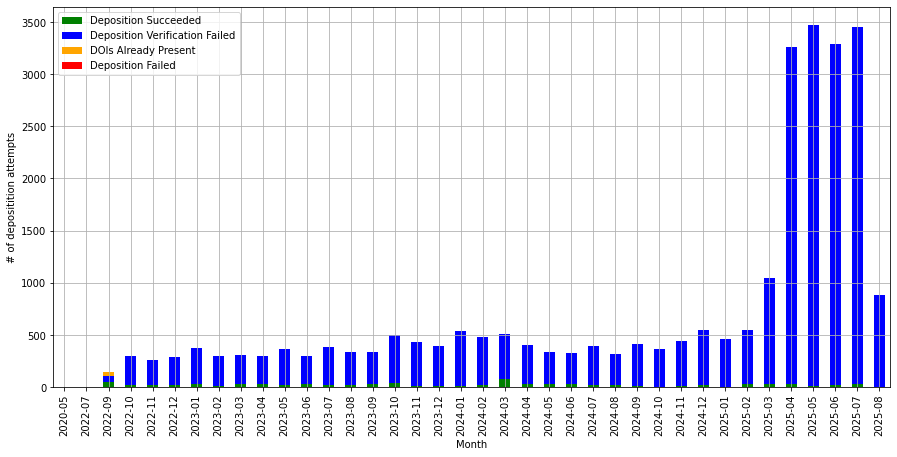

In [8]:
def plot_attempts_by_month_and_status(df):
    counts_by_month_and_status = pandas.DataFrame({
        state: df[df["deposition_status"] == state].value_counts("attempted_at_year_month")
        for state in df["deposition_status"].unique()
    })
    return counts_by_month_and_status, counts_by_month_and_status.plot.bar(
        color=color_by_deposition_status,
        figsize=(15, 7),
        grid=True,
        stacked=True,
        xlabel="Month",
        ylabel="# of depositition attempts",
    )
_ = plot_attempts_by_month_and_status(attempted_depositions)

Let's look only at deposition attempts after this date. All of these were done automatically, without user intervention.
Also filter out any "Verification Failed" attempts because these are only related to our current deposition process.

In [9]:
cutoff_automated_depositions_year_month = "2022-09"
automated_depositions = attempted_depositions[attempted_depositions["attempted_at_year_month"] > cutoff_automated_depositions_year_month]
automated_depositions = automated_depositions[automated_depositions["deposition_status"] != "Deposition Verification Failed"]
automated_depositions

,doi,manuscript,received_at,file_status,id_deposition_attempt,attempted_at,deposition_status,attempted_at_year_month
236,10.1101/2022.02.04.478830,RC-2022-01582,2022-09-29 09:03:01.737371,Valid,237,2022-10-02 05:23:02.429180,Deposition Succeeded,2022-10
286,10.1101/2022.05.16.492059,RC-2022-01487,2022-09-21 16:03:01.613797,Valid,287,2022-10-03 02:23:13.750940,Deposition Succeeded,2022-10
289,10.1101/2021.09.21.461257,RC-2021-01068,2022-10-03 11:03:02.012266,Valid,290,2022-10-06 05:23:02.883115,DOIs Already Present,2022-10
290,10.1101/2022.07.22.501103,RC-2022-01600,2022-10-03 20:03:02.053790,Valid,291,2022-10-06 05:23:02.883115,Deposition Succeeded,2022-10
293,10.1101/2022.05.25.493449,RC-2022-01536,2022-10-05 21:03:03.466077,Valid,294,2022-10-08 05:23:02.394608,Deposition Succeeded,2022-10
...,...,...,...,...,...,...,...,...
26194,10.1101/2024.05.02.592180,RC-2024-02511,2025-07-30 14:03:03.150299,Valid,26195,2025-08-02 05:23:01.965238,Deposition Succeeded,2025-08
26195,10.1101/2025.04.23.650322,RC-2025-03011,2025-07-30 16:03:04.169590,Valid,26196,2025-08-02 05:23:02.876835,Deposition Succeeded,2025-08
26638,10.1101/2025.03.14.642698,RC-2025-02968,2025-07-31 18:03:02.365669,Valid,26639,2025-08-06 02:23:30.596277,Deposition Succeeded,2025-08
26639,10.1101/2024.11.12.623104,RC-2025-02985,2025-08-02 00:03:02.903022,Valid,26640,2025-08-06 02:23:31.391900,Deposition Succeeded,2025-08


(deposition_status
 Deposition Succeeded              774
 DOIs Already Present                4
 Deposition Failed                   1
 Deposition Verification Failed      0
 dtype: int64,
 <AxesSubplot:ylabel='Status of deposition attempts'>)

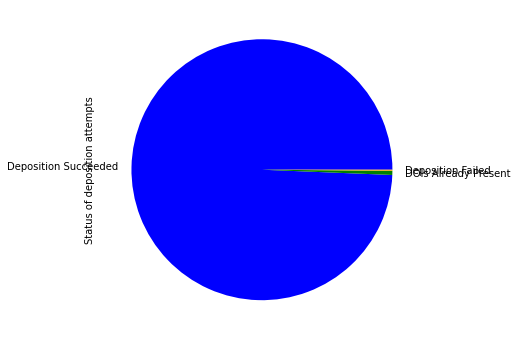

In [10]:
automated_deposition_status_counts = automated_depositions.value_counts("deposition_status")
automated_deposition_status_counts, automated_deposition_status_counts.plot.pie(
    colors=[color_by_deposition_status.get(x, 'grey') for x in deposition_status_counts.index],
    figsize=(11, 6),
    label="Status of deposition attempts",
)

From how many MECAs per month are we depositing DOIs for reviews and replies?

{'median # of successful deposition attempts per month': 23.0}

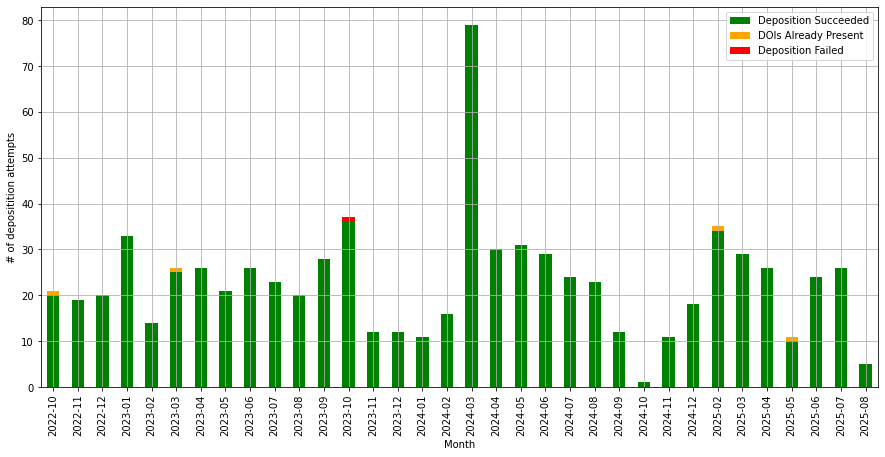

In [11]:
attempts_by_month_and_status, _ = plot_attempts_by_month_and_status(automated_depositions)
{'median # of successful deposition attempts per month': attempts_by_month_and_status["Deposition Succeeded"].median()}